In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/Colab Notebooks/cough_audio_dataset.zip" -d /content/dataset

Archive:  /content/drive/MyDrive/Colab Notebooks/cough_audio_dataset.zip
  inflating: /content/dataset/__notebook_source__.ipynb  
  inflating: /content/dataset/data_audio/data/coughs/audioset_1.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_10.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_100.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_101.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_102.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_103.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_104.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_105.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_106.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_107.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_108.wav  
  inflating: /content/dataset/data_audio/data/coughs/audioset_109.wav  
  inflat

In [3]:
import os
dataset_path = "/content/dataset/data_audio/data"
print(os.listdir(dataset_path))

['not_coughs', 'coughs']


In [4]:
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        audio, _ = librosa.effects.trim(audio)

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        mfcc = np.mean(mfcc.T, axis=0)

        return mfcc
    except:
        return None

In [6]:
features = []
labels = []

for label in ["coughs", "not_coughs"]:
    folder = os.path.join(dataset_path, label)

    for file in os.listdir(folder):
        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(folder, file)
        feat = extract_features(file_path)

        if feat is not None:
            features.append(feat)
            labels.append(label)

X = np.array(features)
y = np.array(labels)

print("Dataset shape:", X.shape)

Dataset shape: (1246, 13)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [9]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

      coughs       0.78      0.57      0.66        98
  not_coughs       0.76      0.89      0.82       152

    accuracy                           0.77       250
   macro avg       0.77      0.73      0.74       250
weighted avg       0.77      0.77      0.76       250

[[ 56  42]
 [ 16 136]]


In [10]:
import joblib

joblib.dump(model, "/content/drive/MyDrive/cough_model.pkl")

['/content/drive/MyDrive/cough_model.pkl']

In [12]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

dataset_path = "/content/dataset/data_audio/data"
spec_path = "/content/spectrograms"

os.makedirs(spec_path, exist_ok=True)

for label in ["coughs", "not_coughs"]:
    os.makedirs(os.path.join(spec_path, label), exist_ok=True)

    folder = os.path.join(dataset_path, label)

    for file in os.listdir(folder):
        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(folder, file)

        try:
            audio, sr = librosa.load(file_path, sr=16000)

            spec = librosa.feature.melspectrogram(y=audio, sr=sr)
            spec_db = librosa.power_to_db(spec, ref=np.max)

            plt.figure(figsize=(3,3))
            librosa.display.specshow(spec_db, sr=sr)
            plt.axis('off')

            save_path = os.path.join(spec_path, label, file.replace(".wav", ".png"))
            plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
            plt.close()

        except:
            continue

print("Spectrograms ready 🔥")

Spectrograms ready 🔥


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    spec_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    spec_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 997 images belonging to 2 classes.
Found 249 images belonging to 2 classes.


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 206ms/step - accuracy: 0.6700 - loss: 0.6518 - val_accuracy: 0.6305 - val_loss: 0.6476
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.7362 - loss: 0.5383 - val_accuracy: 0.6827 - val_loss: 0.6113
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.7864 - loss: 0.4653 - val_accuracy: 0.6506 - val_loss: 0.6904
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.8205 - loss: 0.4082 - val_accuracy: 0.7269 - val_loss: 0.5956
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.8736 - loss: 0.3070 - val_accuracy: 0.7390 - val_loss: 0.6147
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.8786 - loss: 0.2828 - val_accuracy: 0.7068 - val_loss: 0.7103
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9127 - loss: 0.2138 - val_accuracy: 0.6787 - val_loss: 0.9625
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.8957 - loss: 0.2342 - val_accuracy: 0.7229

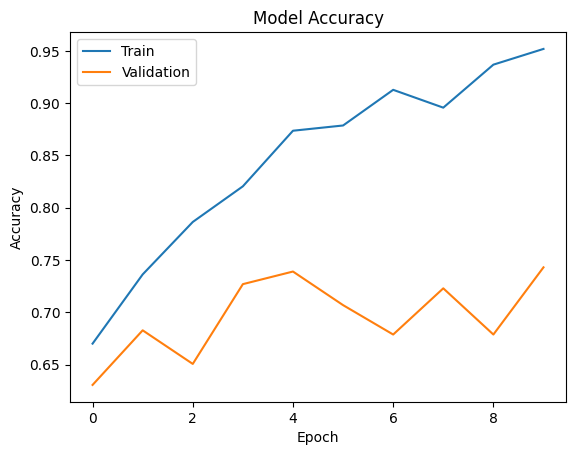

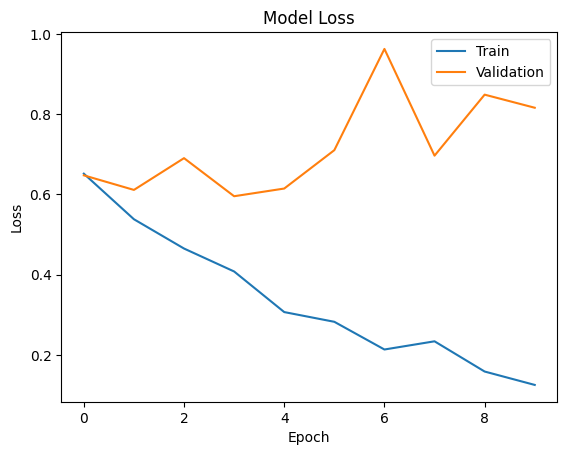

In [16]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [17]:
model.save("/content/drive/MyDrive/cough_cnn_model.h5")

In [18]:
plt.savefig("/content/drive/MyDrive/accuracy_graph.png")
plt.savefig("/content/drive/MyDrive/loss_graph.png")

<Figure size 640x480 with 0 Axes>

In [19]:
report = classification_report(y_test, y_pred)

with open("/content/drive/MyDrive/report.txt", "w") as f:
    f.write(report)